# F8 — Week 12 Performance Review

**Objective**: Review the optimisation performance of F8 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F8 (8D input, 1D output, maximisation)

This notebook loads the Week 12 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 8
N_DIMS = 8
N_INITIAL = 40
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f8/'

## Step 1 — Load Data

In [2]:
# Load Week 12 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F8 — Week 11 Data Summary
  Input dimensions:  8
  Total samples:     51
  Initial samples:   40
  Submissions:       11
  Input shape:       (51, 8)
  Output shape:      (51,)
  Best output:       9.98247
  Worst output:      5.59219

Sample | x1 | x2 | x3 | x4 | x5 | x6 | x7 | x8 | y
-------------------------------------------------------------------------------------------------------------------------
   1(init) | 0.604994 | 0.292215 | 0.908453 | 0.355506 | 0.201669 | 0.575338 | 0.310311 | 0.734281 | 7.39872
   2(init) | 0.178007 | 0.566223 | 0.994862 | 0.210325 | 0.320153 | 0.707909 | 0.635384 | 0.107132 | 7.00523
   3(init) | 0.009077 | 0.811626 | 0.520520 | 0.075687 | 0.265112 | 0.091652 | 0.592415 | 0.367320 | 8.45948
   4(init) | 0.506028 | 0.653730 | 0.363411 | 0.177981 | 0.093728 | 0.197425 | 0.755827 | 0.292472 | 8.28401
   5(init) | 0.359909 | 0.249076 | 0.495997 | 0.709215 | 0.114987 | 0.289207 | 0.557295 | 0.593882 | 8.60612
   6(init) | 0.778818 | 0.003419 | 0.337983 | 

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

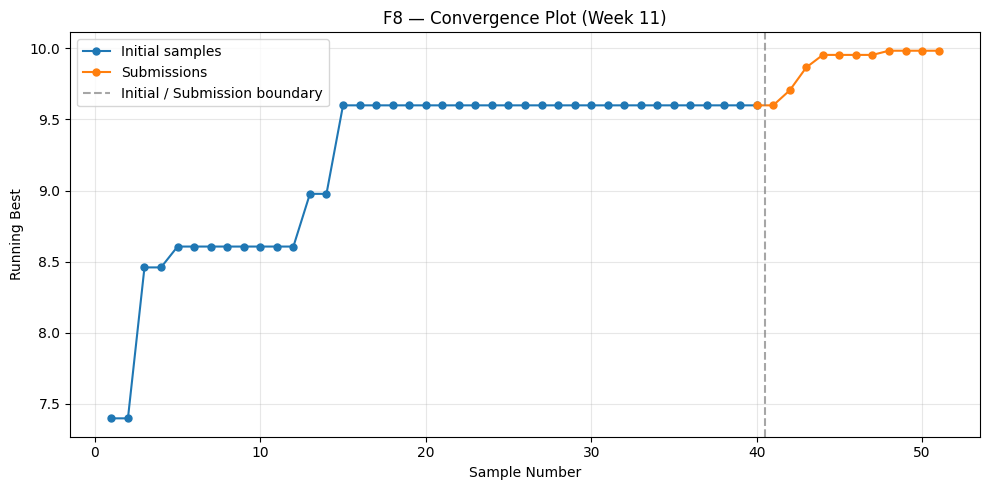

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

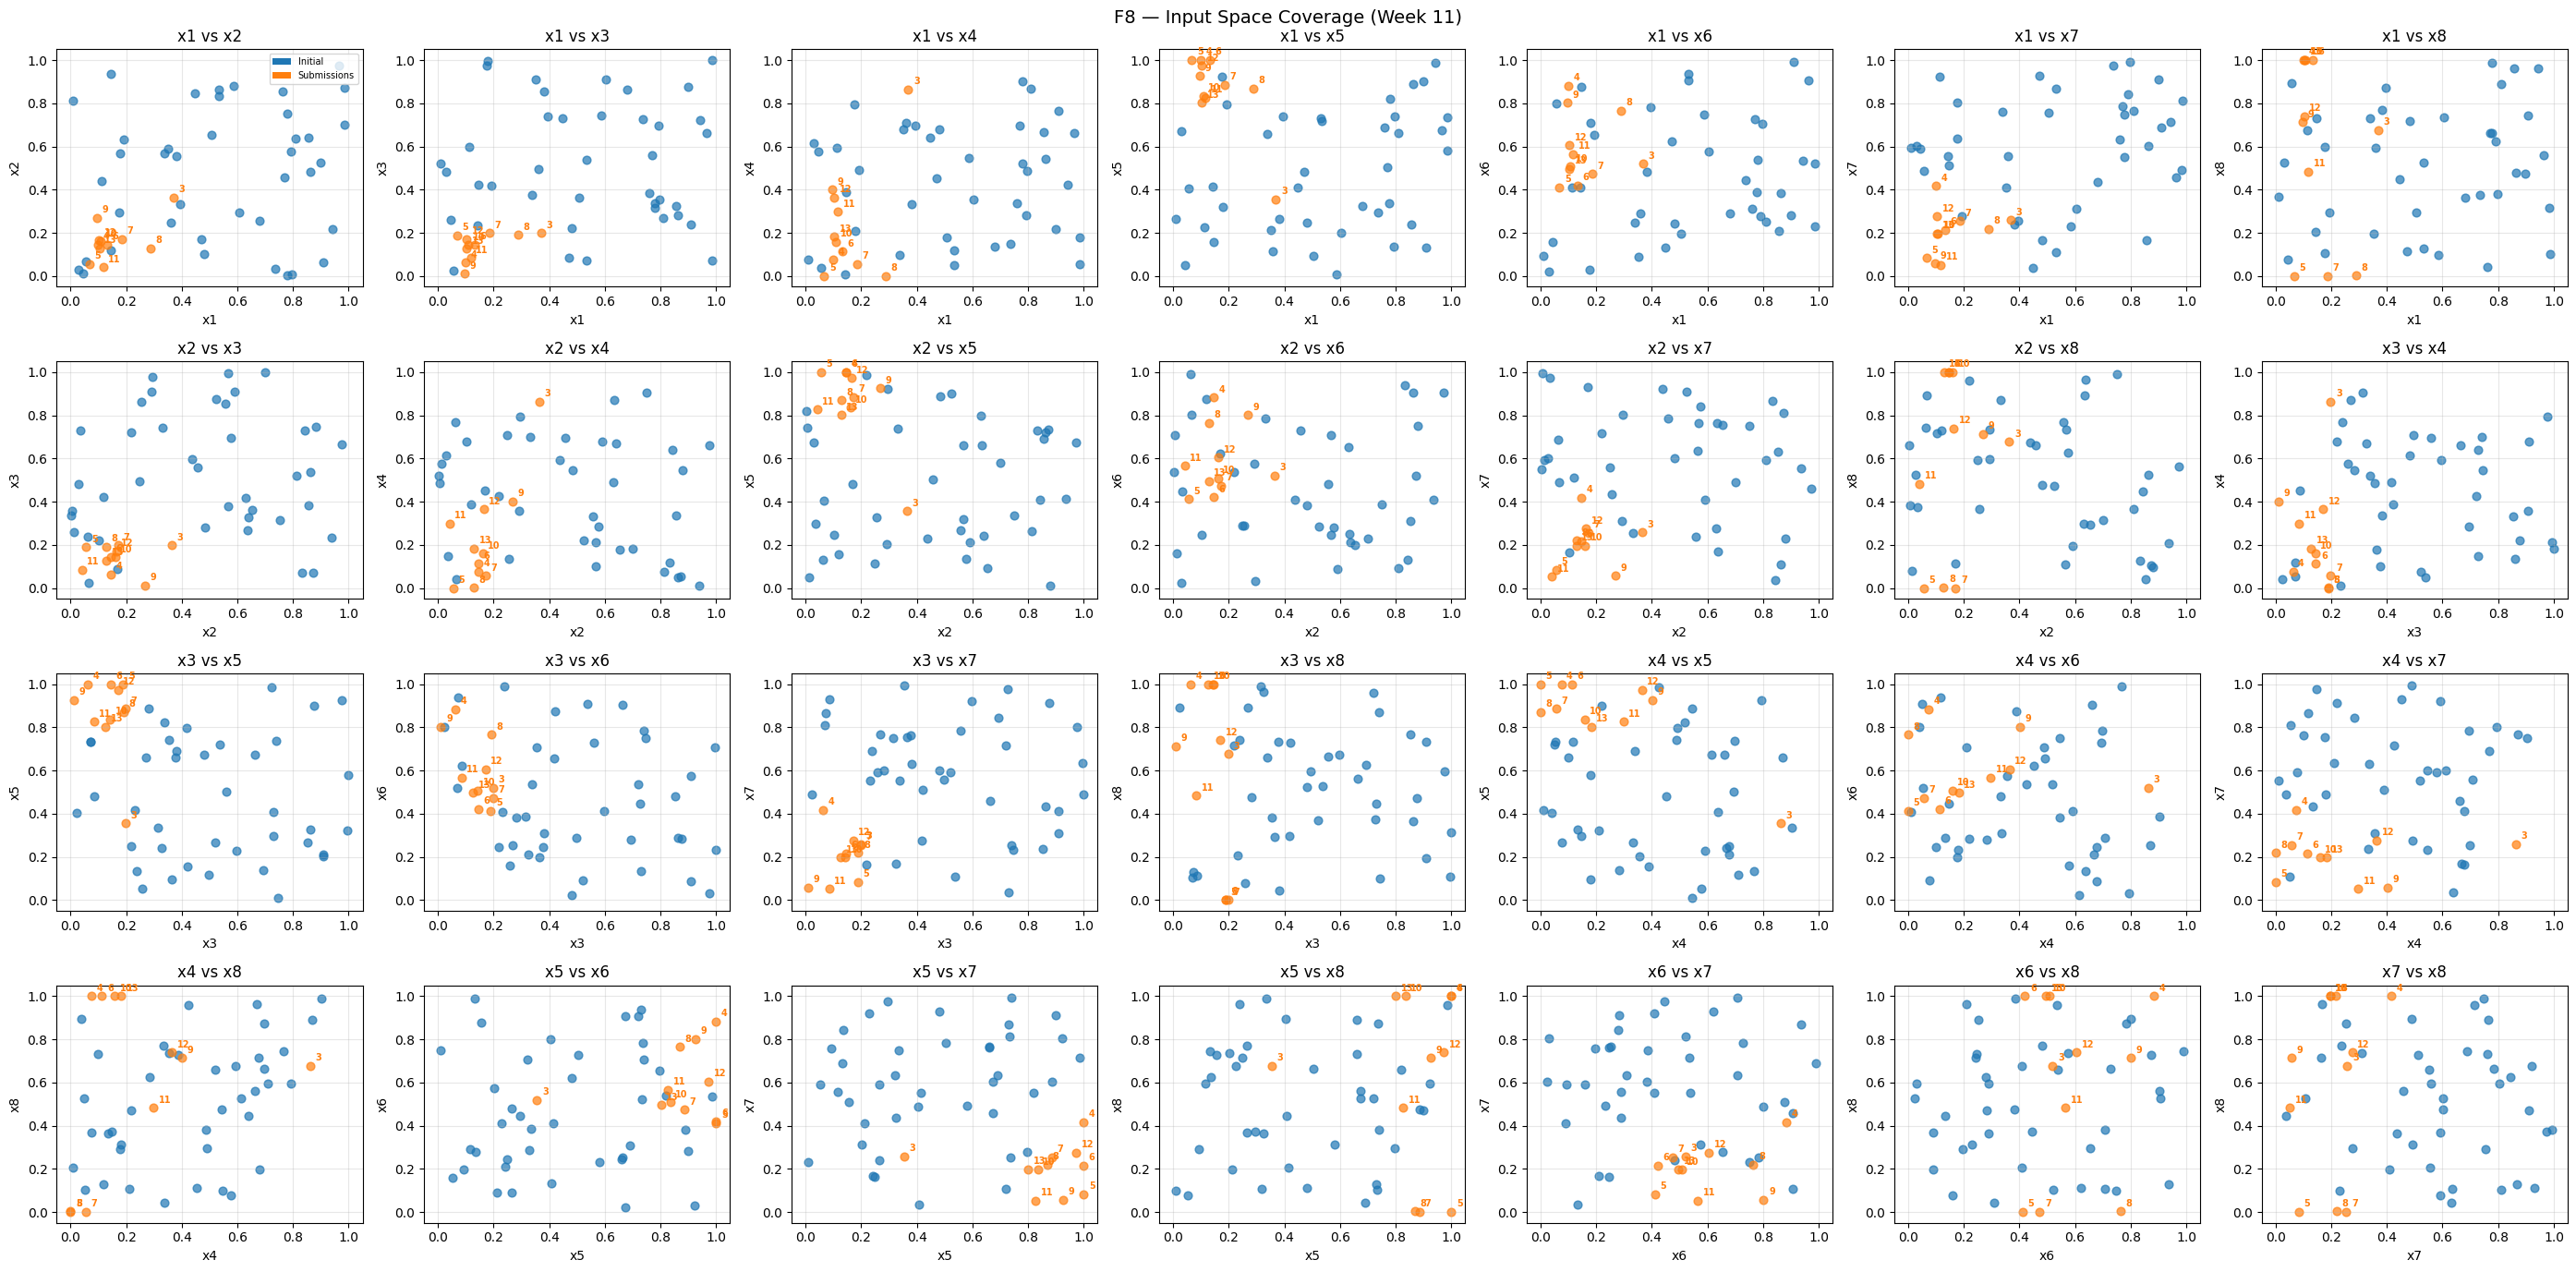

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: SFGP Matérn-2.5 ARD, Standardize(m=1)
- **Acquisition**: qEI, XI=0.01
- **Key hyperparameters**: noise_lb=1e-7, 30 restarts, 4096 raw samples, 256 MC

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     9.59848
Best value (final):       9.98247
Improvements:             4/11
Max consecutive no-improve: 3
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |        9.18047 |        9.59848 | ✗
   4 |        9.70407 |        9.70407 | ✓
   5 |        9.86504 |        9.86504 | ✓
   6 |        9.95303 |        9.95303 | ✓
   7 |        9.91584 |        9.95303 | ✗
   8 |        9.78629 |        9.95303 | ✗
   9 |        9.73921 |        9.95303 | ✗
  10 |        9.98247 |        9.98247 | ✓
  11 |        9.90953 |        9.98247 | ✗
  12 |        9.90994 |        9.98247 | ✗
  13 |         9.9824 |        9.98247 | ✗


### Evaluation

F8 has shown **moderate progress** with **4 improvements** in 10 submission rounds. The best value moved from 9.598 (initial) to 9.982 — incremental gains in a higher-dimensional 8D space.

Key observations:
- 4/10 submissions improved the running best — tied with F6 for the highest improvement count
- Maximum 3 consecutive non-improving submissions — just at the stalling threshold
- The SFGP with Matérn-2.5 ARD and Standardize(m=1) is a solid baseline for this 8D problem
- qEI with XI=0.01 provides slight exploration bias, but the high dimensionality (8D) makes global search inherently difficult
- With 40 initial samples and 10 submissions (50 total) in 8D, the data density is still very sparse
- 28 pair plots across the 8D space give comprehensive coverage of the input relationships

**Stalling status**: YES (borderline) — exactly 3 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

F8 shows moderate progress (4/10 improvements) in the most challenging 8D space. Refinements:

1. **Increase XI from 0.01 to 0.05** — The current expected improvement exploration parameter is very small, making qEI nearly greedy. A larger XI encourages more exploration of uncertain regions in this high-dimensional space.

2. **Increase MC samples from 256 to 512** — The qEI acquisition function estimate improves with more MC samples, reducing the variance of the acquisition value estimate in 8D.

3. **Lower noise floor** — The noise_lb=1e-7 is already very low. Verify this isn't causing numerical issues in the Cholesky decomposition. If stable, this is fine.

4. **Increase raw samples from 4096 to 8192** — The 8D space is vast. More raw candidate points for the acquisition optimiser improve coverage of the search space.

5. **Consider switching to qLogNEI** — The log-transformed EI (qLogNEI) is more numerically stable than qEI for large output ranges and high dimensions. This could improve acquisition optimisation quality.

**Priority**: MEDIUM — F8 is making incremental progress but the high dimensionality means each improvement is valuable. Fine-tuning could accelerate convergence.

## Step 6 — Week 12 Optimisation Run

### Strategy Changes (Week 12)

1. **qEI → qLogNEI** — Log-transformed NEI is numerically stabler in 8D; no best_f/XI parameter needed (uses X_baseline instead).
2. **Multi-restart MLL fitting (≥30 restarts)** — Week 9 used a single fit_gpytorch_mll call. Adding 30 random restarts ensures robust hyperparameter estimation in 8D.
3. **MC samples: 256 → 512** — Reduces acquisition estimate variance in high dimensions.
4. **Raw samples: 4096 → 8192** — Better coverage of the vast 8D search space for acquisition optimisation.
5. **Post-fit Cholesky stability check** — With noise_lb=1e-7, verify the Cholesky decomposition is numerically stable after fitting.

In [6]:
# ── Imports & Configuration ───────────────────────────────────────────────────
import torch
import copy
import warnings
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

# ── Hyperparameters ──
KERNEL_NU = 2.5        # Matérn smoothness — unchanged from week 9
ARD_NUM_DIMS = 8       # 8D input
NOISE_LB = 1e-7        # Very tight noise floor — unchanged
N_MLL_RESTARTS = 30    # NEW: multi-restart MLL fitting (was single fit)
MC_SAMPLES = 512       # Increased from 256
Q_BATCH = 1            # Single candidate (8D is too sparse for batch)
NUM_RESTARTS = 30      # L-BFGS restarts for acquisition — unchanged
RAW_SAMPLES = 8192     # Increased from 4096 for better 8D coverage

print("=== F8 Week 12 Configuration ===")
print(f"Kernel: Matérn-{KERNEL_NU} ARD (d={ARD_NUM_DIMS})")
print(f"Noise floor: {NOISE_LB}")
print(f"MLL restarts: {N_MLL_RESTARTS} (was 1)")
print(f"Batch size q={Q_BATCH}")
print(f"Raw samples: {RAW_SAMPLES} (was 4096)")
print(f"Acquisition restarts: {NUM_RESTARTS}")
print(f"MC samples: {MC_SAMPLES} (was 256)")
print(f"Acquisition: qLogNEI (was qEI)")
print(f"Output transform: Standardize(m=1)")

=== F8 Week 12 Configuration ===
Kernel: Matérn-2.5 ARD (d=8)
Noise floor: 1e-07
MLL restarts: 30 (was 1)
Batch size q=1
Raw samples: 8192 (was 4096)
Acquisition restarts: 30
MC samples: 512 (was 256)
Acquisition: qLogNEI (was qEI)
Output transform: Standardize(m=1)


In [7]:
# ── Data Preparation ──────────────────────────────────────────────────────────
# Convert numpy arrays (from review cells) to float64 tensors
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1)

print(f"=== Data Preparation ===")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Output range: [{outputs.min():.6f}, {outputs.max():.6f}]")
print(f"All positive: {(outputs > 0).all()}")
print(f"Transform: Standardize(m=1) only (no log)")

=== Data Preparation ===
X_train shape: torch.Size([51, 8])
Y_train shape: torch.Size([51, 1])
Output range: [5.592193, 9.982473]
All positive: True
Transform: Standardize(m=1) only (no log)


In [8]:
# ── GP Fitting: Multi-restart MLL with Matérn-2.5 + Standardize(m=1) ──────────
# 30 MLL restarts (was single fit in week 9) + Cholesky stability check

best_model = None
best_loss = float("inf")

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="The input matches the stored training data")

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)
    
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
    covar = ScaleKernel(MaternKernel(nu=KERNEL_NU, ard_num_dims=ARD_NUM_DIMS))
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood,
                         outcome_transform=Standardize(m=1))
    
    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.1 * Y_train.var().item()
    model.covar_module.outputscale = 1.0
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
    except Exception:
        print(f"{seed:>8d} {'FAILED':>12}")
        continue
    
    model.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, model.train_targets).item()
    
    print(f"{seed:>8d} {loss:>12.4f}")
    
    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

warnings.filterwarnings("default", category=RuntimeWarning)

assert best_model is not None, "All MLL restarts failed!"
best_model.eval()

# Extract fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
noise = best_model.likelihood.noise.detach().item()
outputscale = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*50}")
print(f"Best MLL loss: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters (Matérn-{KERNEL_NU} ARD):")
for i in range(ARD_NUM_DIMS):
    print(f"  ℓ_{i} (x{i+1}): {ls[i]:.6f}")
print(f"  Output scale: {outputscale:.6f}")
print(f"  Noise:        {noise:.8f}")

# Cholesky stability check (R11)
print(f"\n--- Cholesky Stability Check ---")
try:
    with torch.no_grad():
        K = best_model.covar_module(X_train).evaluate()
        K += noise * torch.eye(K.shape[0], dtype=K.dtype)
        L = torch.linalg.cholesky(K)
    print(f"✓ Cholesky decomposition succeeded (condition OK)")
    print(f"  Max diagonal: {L.diag().max().item():.6f}")
    print(f"  Min diagonal: {L.diag().min().item():.6f}")
except Exception as e:
    print(f"⚠ Cholesky decomposition FAILED: {e}")
    print(f"  Consider increasing NOISE_LB from {NOISE_LB}")


 Restart      Neg MLL
----------------------
       0      -6.7937
       1      -6.7937
       2      -6.7937
       3      -6.7937
       4      -6.7937
       5      -6.7937
       6      -6.7937
       7      -6.7937
       8      -6.7937
       9      -6.7937
      10      -6.7937
      11      -6.7937
      12      -6.7937
      13      -6.7937
      14      -6.7937
      15      -6.7937
      16      -6.7937
      17      -6.7937
      18      -6.7937
      19      -6.7937
      20      -6.7937
      21      -6.7937
      22      -6.7937
      23      -6.7937
      24      -6.7937
      25      -6.7937
      26      -6.7937
      27      -6.7937
      28      -6.7937
      29      -6.7937

Best MLL loss: -6.793670
Fitted Hyperparameters (Matérn-2.5 ARD):
  ℓ_0 (x1): 9.794416
  ℓ_1 (x2): 13.615168
  ℓ_2 (x3): 7.903808
  ℓ_3 (x4): 13.991418
  ℓ_4 (x5): 20.198490
  ℓ_5 (x6): 13.398307
  ℓ_6 (x7): 10.036533
  ℓ_7 (x8): 1303.758437
  Output scale: 253.181193
  Noise:        0.000000

In [9]:
# ── Acquisition Optimisation: qLogNEI (replacing qEI) ─────────────────────────
# q=1 for 8D, no distance selection needed

import numpy as np

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

bounds = torch.tensor([[0.0]*ARD_NUM_DIMS, [1.0]*ARD_NUM_DIMS], dtype=torch.float64)
candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=Q_BATCH,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"=== Acquisition Results (qLogNEI, q={Q_BATCH}) ===")
print(f"Acquisition value: {acq_value.item():.6f}")

# Get posterior prediction
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_mean = posterior.mean.squeeze().item()

x_new = candidates.squeeze().detach().cpu().numpy()
x_new = np.clip(x_new, 0.0, 0.999999)

proposed_query = "-".join(f"{v:.6f}" for v in x_new)

# Duplicate check
is_duplicate = False
for i in range(len(inputs)):
    if np.allclose(x_new, inputs[i], atol=1e-6):
        is_duplicate = True
        break

print(f"\nProposed point: [{', '.join(f'{v:.6f}' for v in x_new)}]")
print(f"Predicted mean: {pred_mean:.6f}")
print(f"Current best:   {outputs.max():.6f}")
print(f"Duplicate: {is_duplicate}")
print(f"\n>>> SUBMISSION: {proposed_query}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


=== Acquisition Results (qLogNEI, q=1) ===
Acquisition value: -6.997770

Proposed point: [0.111519, 0.131344, 0.144289, 0.182906, 0.817329, 0.512297, 0.187727, 0.999999]
Predicted mean: 9.983074
Current best:   9.982473
Duplicate: False

>>> SUBMISSION: 0.111519-0.131344-0.144289-0.182906-0.817329-0.512297-0.187727-0.999999


Top-2 dims: x3, x1 (ℓ=7.9038, 9.7944)
Fixed dims: x7=0.1877, x6=0.5123, x2=0.1313, x4=0.1829, x5=0.8173, x8=1.0000


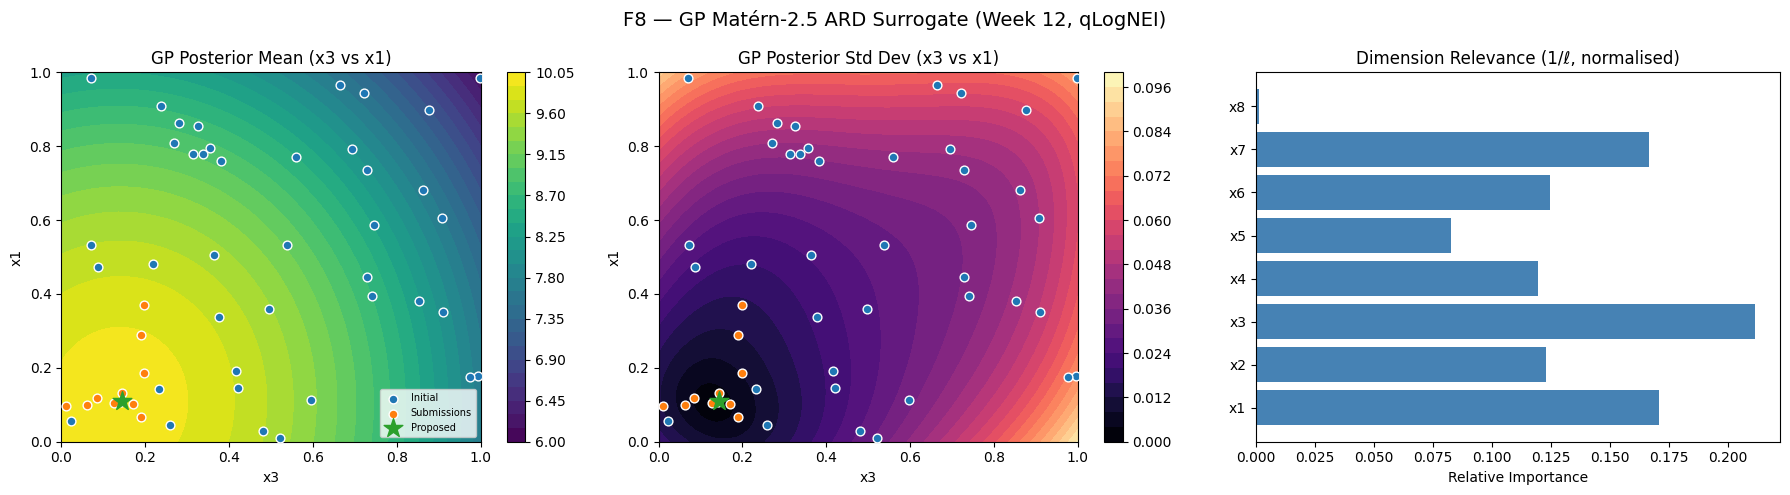

In [10]:
# ── Three-Panel Surrogate Visualisation + Dimension Relevance ─────────────────
# Top-2 relevant dimensions (shortest lengthscales)

sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: x{top2[0]+1}, x{top2[1]+1} (ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d+1}={x_new[d]:.4f}" for d in fix_dims))

GRID_RES = 60  # 60×60 for 8D (lower than 80 for speed)
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(x_new, (GRID_RES * GRID_RES, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    mean_grid = posterior.mean.squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)
    std_grid = posterior.variance.sqrt().squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)

X_initial = inputs[:N_INITIAL]
X_submissions = inputs[N_INITIAL:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean
c1 = axes[0].contourf(G0, G1, mean_grid, levels=30, cmap="viridis")
axes[0].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5, label="Initial")
axes[0].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5, label="Submissions")
axes[0].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6, label="Proposed")
axes[0].set_title(f"GP Posterior Mean (x{top2[0]+1} vs x{top2[1]+1})")
axes[0].set_xlabel(f"x{top2[0]+1}")
axes[0].set_ylabel(f"x{top2[1]+1}")
axes[0].legend(fontsize=7)
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(G0, G1, std_grid, levels=30, cmap="magma")
axes[1].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5)
axes[1].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5)
axes[1].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]+1} vs x{top2[1]+1})")
axes[1].set_xlabel(f"x{top2[0]+1}")
axes[1].set_ylabel(f"x{top2[1]+1}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(ARD_NUM_DIMS), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(ARD_NUM_DIMS))
axes[2].set_yticklabels([f"x{j+1}" for j in range(ARD_NUM_DIMS)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F8 — GP Matérn-2.5 ARD Surrogate (Week 12, qLogNEI)", fontsize=14)
plt.tight_layout()
plt.show()

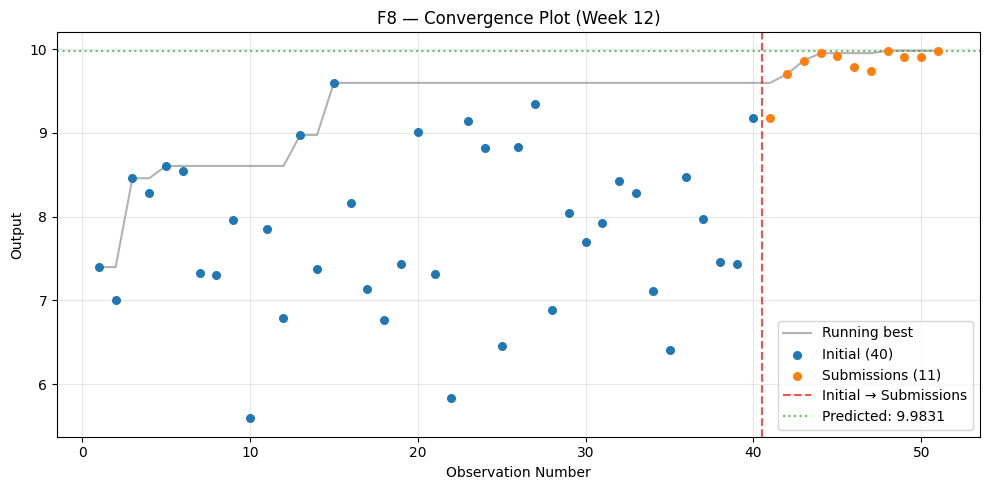

Running best at Week 12 end: 9.982473
Predicted value for proposed point: 9.9831

>>> FINAL SUBMISSION: 0.111519-0.131344-0.144289-0.182906-0.817329-0.512297-0.187727-0.999999


In [11]:
# ── Convergence Plot ──────────────────────────────────────────────────────────
y_all = outputs.ravel()
running_best = np.maximum.accumulate(y_all)
obs_idx = np.arange(1, len(y_all) + 1)

plt.figure(figsize=(10, 5))
plt.plot(obs_idx, running_best, color="grey", linewidth=1.5, alpha=0.6, label="Running best")

n_submissions = len(y_all) - N_INITIAL
plt.scatter(obs_idx[:N_INITIAL], y_all[:N_INITIAL], c="tab:blue", s=30, zorder=3, label=f"Initial ({N_INITIAL})")
plt.scatter(obs_idx[N_INITIAL:], y_all[N_INITIAL:], c="tab:orange", s=30, zorder=3, label=f"Submissions ({n_submissions})")

plt.axvline(x=N_INITIAL + 0.5, color="red", linestyle="--", alpha=0.7, label="Initial → Submissions")
plt.axhline(y=pred_mean, color="tab:green", linestyle=":", alpha=0.7, label=f"Predicted: {pred_mean:.4f}")

plt.xlabel("Observation Number")
plt.ylabel("Output")
plt.title("F8 — Convergence Plot (Week 12)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 12 end: {running_best[-1]:.6f}")
print(f"Predicted value for proposed point: {pred_mean:.4f}")
print(f"\n>>> FINAL SUBMISSION: {proposed_query}")